<h1><b>Titanic Dataset Hands-on Data Overview, EDA and Classification Machine Learning</b></h1>

Either you are entering into Kaggle first time or you have been participating into the Kaggle competitions, if you are looking for some cool ideas to explore on adding great EDA to Hyperparameter tuning, you are at the best notebook. I have included most possible data overview, exploratory data analysis with findings included, data visualization with findings, data pre-processing, machine learning life-cycle, and saving model locally. Most importantly, this notebook is being constantly upgraded with additional ML techniques, visualizations and EDA with great insights.

I hope you are going to learn a ton from this notebook. This notebook will be constantly updated, and this is just beginning, and I want learners to take the best advantage out of this notebook and analysis. so please do not forget to check the most updated one next time as I am updating this notebook frequently with additional analysis, visualization, comments and models based on the viewers comments!<br><br>
**If you want to  learn something specific, please feel free to COMMENT, I will provide in-depth deep dive into it. Also, if you liked my work on this, please hit UPVOTE, so that it will reach more learners.** <br><br>
For better practice, I will be using training data, and split to validation set to provide full practice of data preprocessing, but in the titanic specific data, we do not need to perform train-test split which I have used in order to do the submission to Kaggle.
<br><br>
Please also do not forget to check my YouTube channel as I am constructing hands-on tutorial from this notebook, and this will be updated there:
https://www.youtube.com/@DataSpeaks4u

<h1><b>Basic Imports

Let's begin our project with importing necessary libraries and modules. Working with python is really powerful for Data Science projects with very powerful libraries, modules and frameworks that will help you with not having to write code from scratch to accomplish specific tasks, including data visualization, exploratory data analysis, machine learning and deployments. Please go through the imports below, and let me know in comments if you got any questions.

In [1]:
# =============================
# Core data and computation libs
# =============================
import numpy as np  # NumPy: fundamental package for fast numerical computing (arrays, random numbers, linear algebra)
import pandas as pd  # pandas: tabular data structures (DataFrame/Series) for data loading, cleaning, joins, and EDA

# =============================
# Visualization libraries
# =============================
import matplotlib.pyplot as plt  # Matplotlib (stateful pyplot API): low-level plotting, figure/axes control
import seaborn as sns  # Seaborn: higher-level statistical plots with nicer defaults; built on top of Matplotlib

# ===============================================================
# scikit-learn utilities: data split, preprocessing, and pipelines
# ===============================================================
# Train/validation/test splitting (train_test_split),
# StratifiedKFold for balanced class distributions across folds during CV,
# and GridSearchCV for exhaustive hyperparameter search with cross-validation.
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

# ColumnTransformer lets you apply different preprocessing to different column subsets
# (e.g., numeric vs categorical pipelines).
from sklearn.compose import ColumnTransformer

# Pipeline chains preprocessing steps and estimator into a single object
# to ensure no data leakage and consistent application during fit/predict.
from sklearn.pipeline import Pipeline

# Common preprocessing transformers:
# - OneHotEncoder: convert categorical features to one-hot/dummy variables.
# - StandardScaler: standardize numeric features (mean=0, std=1), critical for distance-based or linear-margin models.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# SimpleImputer: handle missing values (e.g., strategy='mean' for numeric, 'most_frequent' for categorical).
from sklearn.impute import SimpleImputer

# =======================
# scikit-learn classifiers
# =======================
# Decision Tree: non-linear, interpretable, prone to overfitting if not regularized (max_depth, min_samples_split, etc.).
from sklearn.tree import DecisionTreeClassifier

# Random Forest: ensemble of trees; reduces variance; good baseline for tabular data; handles mixed feature types well.
from sklearn.ensemble import RandomForestClassifier

# K-Nearest Neighbors: instance-based learner; sensitive to scale (hence StandardScaler); choose k via CV.
from sklearn.neighbors import KNeighborsClassifier

# Support Vector Classifier: effective in high-dimensional spaces; sensitive to feature scaling; kernels (linear/RBF/poly).
from sklearn.svm import SVC

# ==============================
# Metrics and diagnostic utilities
# ==============================
from sklearn.metrics import (
    accuracy_score,              # Overall fraction of correct predictions (may be misleading with class imbalance).
    precision_score,             # Of predicted positives, how many are correct (TP / (TP + FP)).
    recall_score,                # Of actual positives, how many were found (TP / (TP + FN)).
    f1_score,                    # Harmonic mean of precision and recall; balances both for imbalanced classes.
    roc_auc_score,               # Area under ROC curve; threshold-independent measure (binary & probability-based).
    classification_report,       # Nicely formatted precision/recall/F1/support per class.
    confusion_matrix,            # 2x2 (binary) or CxC (multi-class) matrix of predicted vs actual counts.
    RocCurveDisplay,             # Helper to plot ROC curve (TPR vs FPR across thresholds).
    PrecisionRecallDisplay       # Helper to plot Precision-Recall curve (especially informative on imbalanced data).
)

# =======================
# Persistence / I/O helper
# =======================
import joblib  # For saving/loading trained models, pipelines, and preprocessors efficiently (pickle-compatible).

# =======================
# Reproducibility controls
# =======================
RANDOM_STATE = 42  # Fixed seed value used wherever estimators/splitters accept random_state for reproducible results.
np.random.seed(RANDOM_STATE)  # Also seed NumPy's RNG when generating synthetic data or random operations outside sklearn.

# =======================
# Sanity message
# =======================
# Basic confirmation that the imports executed without error.
# Useful in notebooks or scripts to ensure environment dependencies are satisfied before proceeding.
print("Imports loaded!🤖")

Imports loaded!🤖


<h3><b>Load the data (Kaggle Built-in Titanic Dataset)

Before loading here, it is important that we load the data into the "INPUT" section to the right panel

In [2]:
train_path = "/kaggle/input/competitions/titanic/train.csv" # These paths can be copied from the data path on right side "Competitions" panel
test_path = "/kaggle/input/competitions/titanic/test.csv" # this is the test data which will be used to evaluate model's performances

<h3><b>Loading the training dataset from the path defined above, and naming it to "df"

In [3]:
# define the df
df = pd.read_csv(train_path) # calling train dataset to be the df

Below, I am using the more friendly printing of ```df.shape``` so that it can be understood easily without confusion which is rows count and which is column count.

In [4]:
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns in the dataset.") # check number of rows and columns in the dataset

There are 891 rows and 12 columns in the dataset.


<h2><b>Quick Overviews of the Data

Understanding data is crucial part of any Data Science and Machine Learning project. Getting quick overview of the data can help us to build foundation for the data understanding. Let's begin small!

df.head() is popular technique to get the top (first) 5 rows of the data. if you just say "df.head()", default rows that are output are 5, but you can change inside the open and close paranthesis, provide any number of rows you like to get, i.e. <code>df.head(2)</code> or <code>df.head(10)</code>.

<h3>Top Rows

In [5]:
# getting the top 5 rows of the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Getting top 3 rows of the dataset
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [7]:
df.head(10) # Looking at the top 10 records from the training dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Understanding last few rows may give us a bit better understanding about the data, how does it look like towards the last.

<h3>Bottom (last) rows

In [8]:
# Getting last 5 rows of the dataset
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [9]:
# Getting last 7 rows of the training dataset
df.tail(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.050,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.125,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.450,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.750,NaN,Q


Looking at the very first few rows or last rows is good idea to get good understanding of the data, however, it is sometimes not sufficient to get full picture of the dataset. If you see the randomly picked up few rows, this will give you much better picture of the dataset while this is going to be much representative. 

.sample() function lets you choose whatever number of randomply picked up rows you want to view, and display the value for you. Every time you run the code, different rows will be picked up. Let's view some randomly picked up rows below:

<h3>Randomly Selected Rows

In [10]:
# Getting sample 5 rows of the dataset. This function will pick the random 5 rows. Notice the index positions
df.sample(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


NOTICE THE INDEX POSITIONS OF EACH RECORDS, THEY ARE RANDOM, NOT IN A SEQUENCE.

In [11]:
df.sample(3) # Let's look at the random 3 records from the training dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
384,385,0,3,"Plotcharsky, Mr. Vasil",male,NaN,0,0,349227,7.8958,NaN,S
210,211,0,3,"Ali, Mr. Ahmed",male,24.0,0,0,SOTON/O.Q. 3101311,7.0500,NaN,S
486,487,1,1,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)",female,35.0,1,0,19943,90.0000,C93,S


In [12]:
df.sample(10) # Also, let's pick random 10 records from the dataset and display belo

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
254,255,0,3,"Rosblom, Mrs. Viktor (Helena Wilhelmina)",female,41.0,0,2,370129,20.2125,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
777,778,1,3,"Emanuel, Miss. Virginia Ethel",female,5.0,0,0,364516,12.4750,NaN,S
436,437,0,3,"Ford, Miss. Doolina Margaret ""Daisy""",female,21.0,2,2,W./C. 6608,34.3750,NaN,S
635,636,1,2,"Davis, Miss. Mary",female,28.0,0,0,237668,13.0000,NaN,S
748,749,0,1,"Marvin, Mr. Daniel Warner",male,19.0,1,0,113773,53.1000,D30,S
701,702,1,1,"Silverthorne, Mr. Spencer Victor",male,35.0,0,0,PC 17475,26.2875,E24,S
32,33,1,3,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,NaN,Q
73,74,0,3,"Chronopoulos, Mr. Apostolos",male,26.0,1,0,2680,14.4542,NaN,C
650,651,0,3,"Mitkoff, Mr. Mito",male,NaN,0,0,349221,7.8958,NaN,S


Looking at the first few rows are great!! But this is not complete picture of the data. We need ways to look at the data by type of data, if there are any missing rows on each columns, what are the data types in each columns are the few ways to understand better picture of the dataset. Let's have a look at them.

<h3>Data Information

In [13]:
# Checking information about the data in overall
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<h3><b>Statistical Summary of Numerical and Categorical Columns

<b>Statistical Summary of Numerical Features</b>
While looking at the first few rows gives us a feel for the data, we need descriptive statistics to understand the distribution, spread, and scale of our numerical variables.

We use the .describe() function, which automatically calculates the following for every numerical column:

- Count: The number of non-missing values (helps identify empty cells).
- Mean: The average value.
- Std (Standard Deviation): How spread out the data is (high value = high variability).
- Min/Max: The range of the data.
- 25%, 50%, 75% (Percentiles): Helps us understand the distribution and detect outliers. The 50% mark is the Median.

<b>Pro Tip<b>: <br>We often add .T (Transpose) at the end. This flips the table so that features are rows and statistics are columns, making it much easier to read when you have many columns!

In [14]:
# Getting quick statistical summary of the numerical columns. Dot T here transposes the rows to columns and columns to rows
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


<h4><b>📊 Analysis: Numerical Feature Insights</b></h4>
<div style="background-color: rgba(76, 175, 80, 0.1); padding: 20px; border-radius: 10px; border-left: 5px solid #4CAF50;">
<p>The <b>.describe().T</b> output provides the statistical "skeleton" of our dataset. Here are the key takeaways from the numerical distributions:</p>

<ul>
    <li><b>Survival Rate (Survived):</b> 
        The mean for <code>Survived</code> is <b>0.384</b>. This tells us that approximately <b>38.4%</b> of the passengers in the training set survived, while the majority (61.6%) did not.
    </li>
    <li><b>Passenger Class (Pclass):</b> 
        The average class is <b>2.3</b>, and the 50% (median) mark is <b>3</b>. This suggests that more than half of the passengers were traveling in 3rd Class, indicating a dataset skewed toward lower-fare tickets.
    </li>
    <li><b>Age Distribution & Missing Values:</b> 
        The <code>count</code> for <code>Age</code> is <b>714</b> (compared to 891 total). This confirms that <b>177 ages are missing</b>. The passengers ranged from infants (<b>0.42 years</b>) to a senior of <b>80 years</b>, with the average passenger being around <b>30 years old</b>.
    </li>
    <li><b>Fare Skewness:</b> 
        The <code>Fare</code> column shows massive variance. While the median fare was only <b>14.45</b>, the maximum was <b>512.33</b>. Since the <code>std</code> (49.69) is higher than the <code>mean</code> (32.20), we know the data is highly skewed by expensive 1st-class tickets.
    </li>
    <li><b>Family Dynamics (SibSp & Parch):</b> 
        The median for both <code>SibSp</code> (siblings/spouses) and <code>Parch</code> (parents/children) is <b>0</b>. This indicates that <b>at least 50% of passengers were traveling alone</b>. However, some large families were present, with a maximum of 8 siblings/spouses.
    </li>
</ul>
</div>

💡 Beginner Tip: Notice the difference between the Mean and the 50% (Median). In the Fare column, the Mean (32) is much higher than the Median (14). This is a classic sign of outliers—a few people paid very high prices, pulling the average up!


<h4><b>Statistical Summary of Categorical (Text) Features</b></h4><br>
Not all data can be averaged! For columns containing text or categories (objects), we use include="object" to see a different set of metrics that help us understand the "classes" within our data.

<u>This summary provides:</u>
- Count: Number of non-null entries.
- Unique: The number of distinct categories (e.g., for Sex, this should be 2: 'male' and 'female').
- Top: The most frequently occurring category (the Mode).
- Freq: How many times that "Top" category appears.

<b>Why this helps<b>: This is the easiest way to spot cardinality issues (like a 'Name' column having too many unique values to be useful) or imbalance (like seeing if 90% of passengers embarked from the same port).

In [15]:
# Getting statistical summary of categorical columns
df.describe(include="object").T

,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


<div style="background-color: rgba(50, 150, 255, 0.1); padding: 20px; border-radius: 10px; border-left: 5px solid #2196F3;">
<p>This summary provides a high-level view of our non-numeric data. Here is what we can observe from the <b>.describe(include="object")</b> output:</p>

<ul>
    <li><b>High Cardinality (Name & Ticket):</b> 
        The <code>Name</code> column has 891 unique values (one for every row), and <code>Ticket</code> has 681. These are "high cardinality" features. We cannot use them directly in a model, but we can <i>engineer</i> them (e.g., extracting Titles like "Mr." or "Miss").
    </li>
    <li><b>Gender Distribution (Sex):</b> 
        There are 2 unique values, with <b>male</b> being the most frequent (<code>top</code>). It appears 577 out of 891 passengers (approx. 65%) were male.
    </li>
    <li><b>Missing Data Alert (Cabin):</b> 
        While there are 891 total rows, <code>Cabin</code> only has a <code>count</code> of 204. This means over <b>77% of the data is missing</b> for this column. We will need to decide whether to drop it or extract the "Deck" letter.
    </li>
    <li><b>Embarkation Points (Embarked):</b> 
        There are 3 unique ports. The most common is <b>S</b> (Southampton), appearing 644 times. Since only 2 values are missing (889 vs 891), this will be easy to impute using the <code>mode</code>.
    </li>
</ul>

<h3>Get the list of Columns

In [16]:
# Checking list of columns
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

<ul>
<li><b>isnull():</b> Scans every cell to see if it is empty (NaN).</li>
<li><b>sum():</b> Adds up all the "True" (missing) values for each column.</li>
</ul>

<h3>Check missing values

In [17]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<h3><b>Quick EDA for Sanity Check

<b>⚖️ Target Variable Balance Check</b>
<ul>
<li><b>value_counts(normalize=True):</b> Converts raw counts into proportions (decimals).</li>
<li><b>* 100:</b> Turns those proportions into percentages for easier reading.</li>
<li><b>round(..., 2):</b> Cleans up the output to 2 decimal places.</li>
</ul>

In [18]:
# Checking balance of the labels
round(df["Survived"].value_counts(normalize=True) * 100, 2)

Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

According to the labels, **61.62%** of the passengers did not survive and **38.38%** of the passengers survived.

In [19]:
# Checking top missing values
df.isna().mean().sort_values(ascending=False).head(10)

Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Name           0.000000
Pclass         0.000000
Survived       0.000000
Sex            0.000000
Parch          0.000000
SibSp          0.000000
dtype: float64

<b>🔗 Numerical Correlation Analysis</b>
<ul>
<li><b>select_dtypes(include=[np.number]):</b> Automatically filters the data to keep only numerical columns, skipping text like Names or Sex.</li>
<li><b>.corr():</b> Calculates the Pearson correlation coefficient (ranging from -1 to +1).</li>
<li><b>numeric_only=True:</b> A safety parameter to ensure the function only processes numbers.</li>
</ul>

Note: We often look for high correlations between features (Multicollinearity). For example, if <b>Pclass</b> and <b>Fare</b> are too highly correlated, they might be telling the model the same thing twice!

In [20]:
# Quick correlation check for numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

corr = round(df[num_cols].corr(numeric_only=True), 4)
display(corr)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.0000,-0.0050,-0.0351,0.0368,-0.0575,-0.0017,0.0127
Survived,-0.0050,1.0000,-0.3385,-0.0772,-0.0353,0.0816,0.2573
Pclass,-0.0351,-0.3385,1.0000,-0.3692,0.0831,0.0184,-0.5495
Age,0.0368,-0.0772,-0.3692,1.0000,-0.3082,-0.1891,0.0961
SibSp,-0.0575,-0.0353,0.0831,-0.3082,1.0000,0.4148,0.1597
Parch,-0.0017,0.0816,0.0184,-0.1891,0.4148,1.0000,0.2162
Fare,0.0127,0.2573,-0.5495,0.0961,0.1597,0.2162,1.0000


<h3><b>Data Visualization for additional data exploration

<ul>
<li><b>Color Scale:</b> Dark Red indicates a strong <b>Positive Correlation</b>, while Dark Blue indicates a strong <b>Negative Correlation</b>.</li>
<li><b>The Goal:</b> We look for features that have a high correlation with "Survived" (our target) and check for <b>Multicollinearity</b> (when two input features are too similar).</li>
</ul>

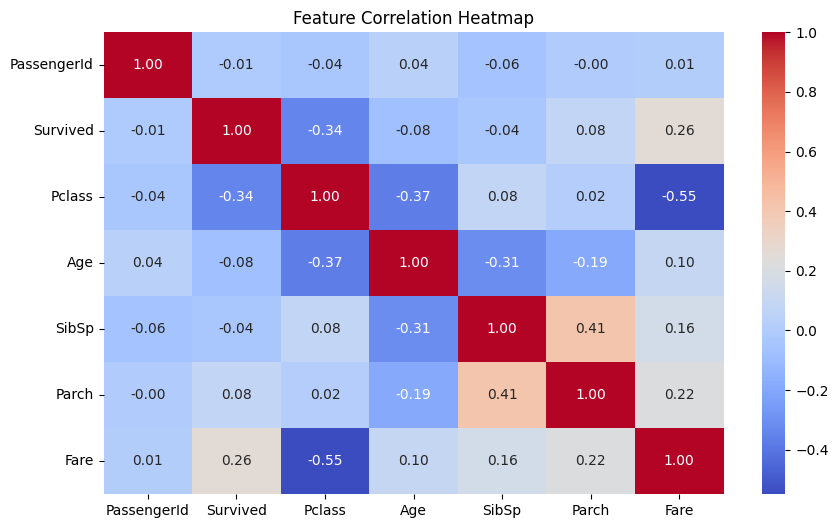

In [21]:
# Correlation heatmap if you want non-interactive one
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [22]:
# import plotly.express as px

# # Creating an interactive heatmap
# fig = px.imshow(corr, 
#                 text_auto='.2f', 
#                 aspect="auto", 
#                 color_continuous_scale='RdBu_r',
#                 title="Interactive Correlation Matrix (Plotly)")

# # Enhancing the layout
# #fig.update_layout(width=800, height=600)
# fig.show()

<b>🌡️ Survival Correlation Analysis</b>
<ul>
<li><b>Why it’s important:</b> It helps us identify <b>Feature Importance</b> (which variables actually matter) and <b>Redundancy</b> (if two variables provide the same information, which can confuse the model).</li>
<li><b>Positive Correlation (Red):</b> As one value increases, the other tends to increase (e.g., higher <b>Fare</b> often correlates with higher <b>Survival</b>).</li>
<li><b>Negative Correlation (Blue):</b> As one value increases, the other decreases (e.g., as <b>Pclass</b> increases from 1 to 3, the <b>Survival</b> rate drops significantly).</li>
</ul>

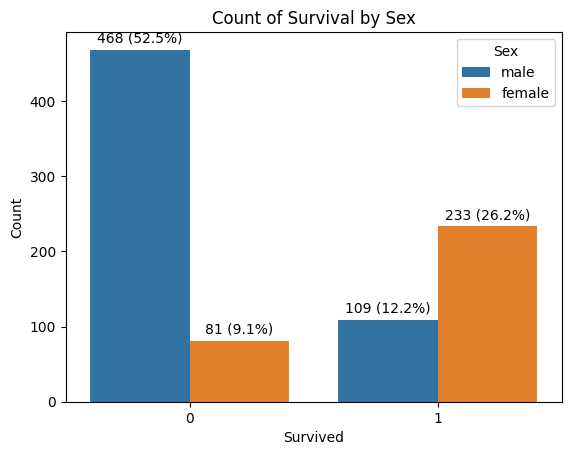

In [23]:
# Countplot of Survived split by Sex
ax = sns.countplot(x='Survived', data=df, hue='Sex')
plt.title("Count of Survival by Sex")
plt.ylabel("Count")

# Total rows for percentage calculation (overall %)
total = len(df)

# Add labels: count + overall percentage
for container in ax.containers:
    labels = [
        f"{int(bar.get_height())} ({bar.get_height()/total:.1%})"
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=3)

plt.show()

In [24]:
# categorical pivot table: Survival based on gender
round(df[["Sex", "Survived"]].groupby(['Sex']).mean(), 3)

,Survived
Sex,
female,0.742
male,0.189


In [25]:
# categorical pivot table: Survival rate by Passenger class
round(df[["Pclass", "Survived"]].groupby(['Pclass']).mean(), 3)

,Survived
Pclass,
1,0.630
2,0.473
3,0.242


Text(0.5, 1.0, 'Age density Distribution by Survival')

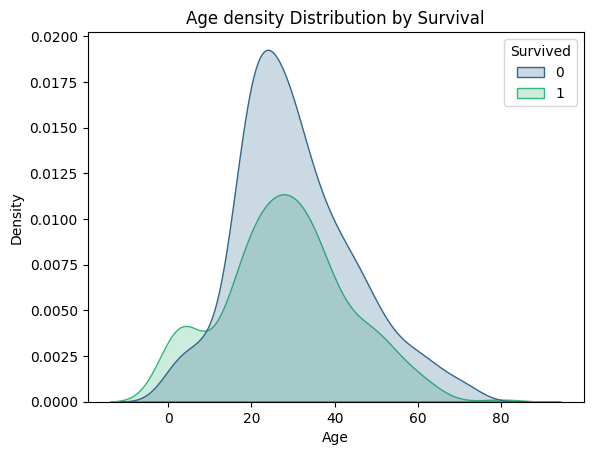

In [26]:
# Age distribution by survival (KDE PLOT)
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, palette='viridis')
plt.title("Age density Distribution by Survival")

Text(0.5, 1.0, 'Relationship between Age, Fare and Survival')

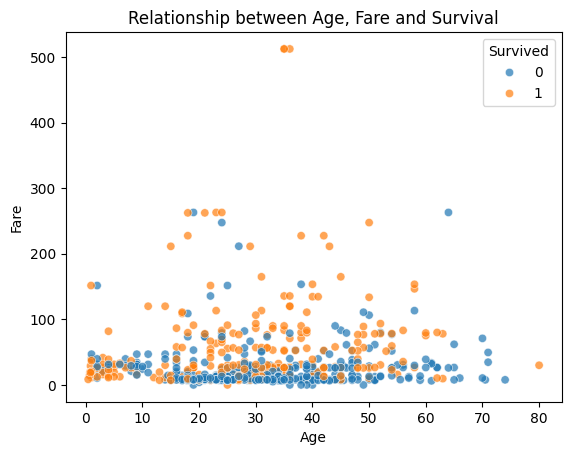

In [27]:
# fair vs age vs survival scatter plot
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', alpha=0.7)
plt.title("Relationship between Age, Fare and Survival")

Text(0.5, 1.0, 'Survival Rate by Family Size')

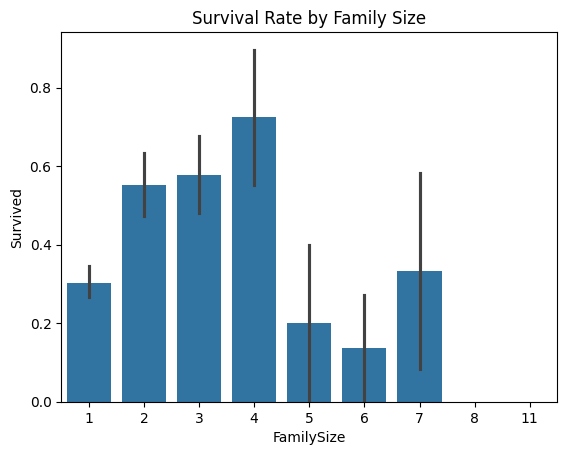

In [28]:
# survival rate by family size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
sns.barplot(data=df, x = 'FamilySize', y = 'Survived')
plt.title("Survival Rate by Family Size")

Text(0.5, 1.0, 'Survival Probability: Sex vs Pclass')

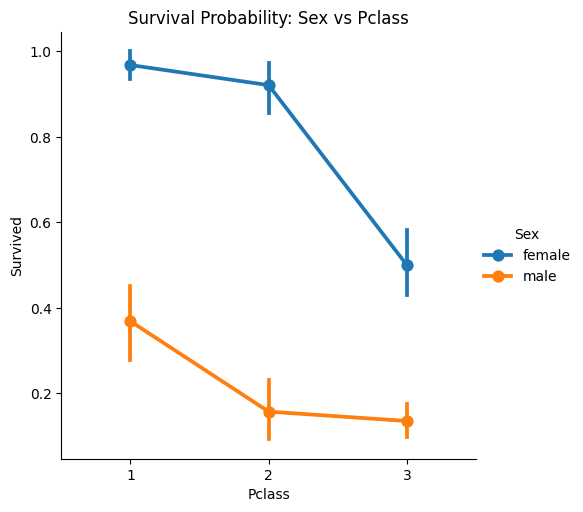

In [29]:
# Passenger class and sex interaction (catplot)
sns.catplot(x='Pclass', y='Survived', hue='Sex', data=df, kind='point')
plt.title("Survival Probability: Sex vs Pclass")

Text(0.5, 1.0, 'Surval by Port of Embarkation and Class')

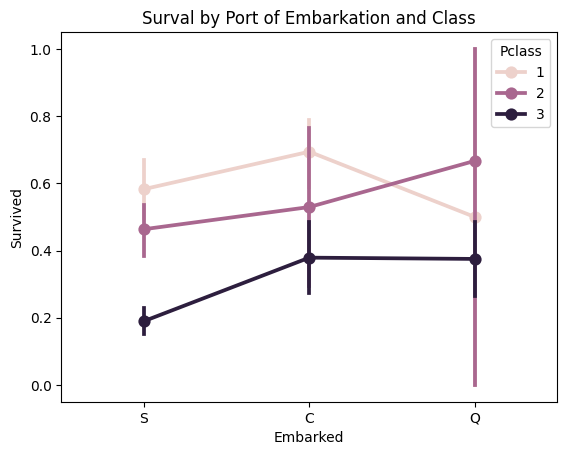

In [30]:
# Embarked port vs Survival vs. Pclass
sns.pointplot(data=df, x='Embarked', y='Survived', hue='Pclass')
plt.title("Surval by Port of Embarkation and Class")

Text(0.5, 1.0, 'Fair Distribution across classes')

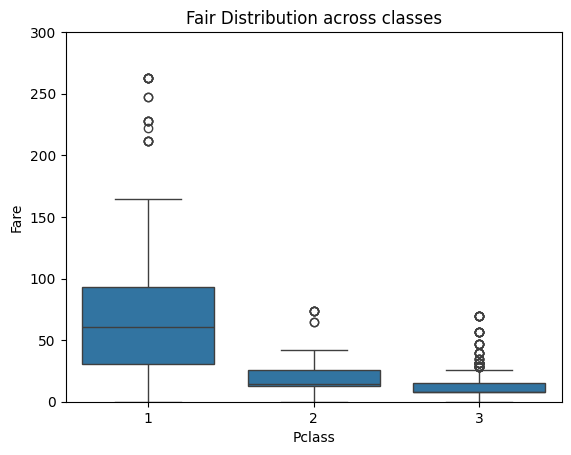

In [31]:
# Fair distribution by class
sns.boxplot(data=df, x = 'Pclass', y = 'Fare')
plt.ylim(0, 300) # Zoom in to ignore extreme outliers for better view
plt.title("Fair Distribution across classes")

Text(0.5, 1.0, 'Missing data Gap')

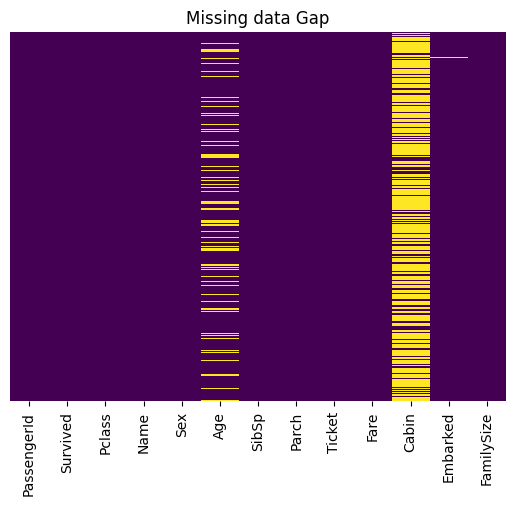

In [32]:
# missing value matrix
# Visualize the "emptiness" of the data 
# to see if Age or Cabin missigness is random or clustered
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing data Gap")

This combines a boxplot and KDE. It’s great for seeing if the age distribution of survivors in 1st class differs from 3rd class.

Text(0.5, 1.0, 'Age/Class Distribution by Surivival')

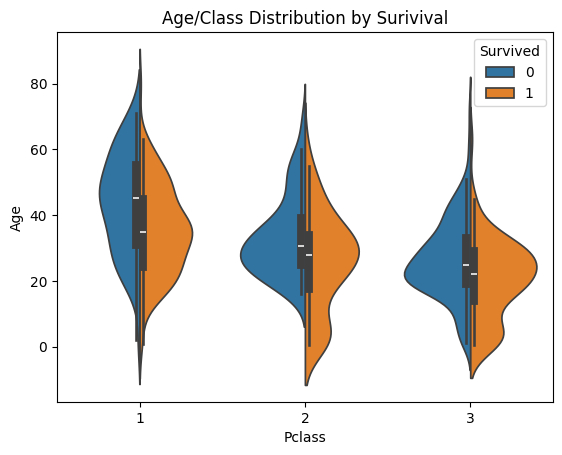

In [33]:
# Violin plot of Age by Passenger class and Survived
sns.violinplot(data=df, x="Pclass", y='Age', hue="Survived", split=True)
plt.title("Age/Class Distribution by Surivival")

You can extract titles (Mr, Mrs, Miss, Master, Dr) from the Name column. Visualizing survival by "Title" often reveals more than "Sex" alone (e.g., "Master" usually refers to young boys).

Text(0.5, 1.0, 'Survival Count by Title')

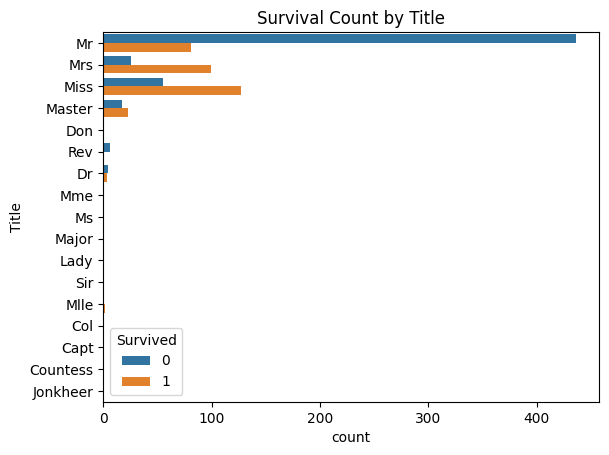

In [34]:
# Title extraction Analysis
# We can extract the title (Mr, Mrs, Miss, Master, Dr) from the Name column.
# Visualizing survival by "Title" often reveals more than "Sex" alone (e.g. Master usually refers to young boys)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
sns.countplot(data=df, y='Title', hue="Survived")
plt.title("Survival Count by Title")

A bird's-eye view of all numerical relationships at once.

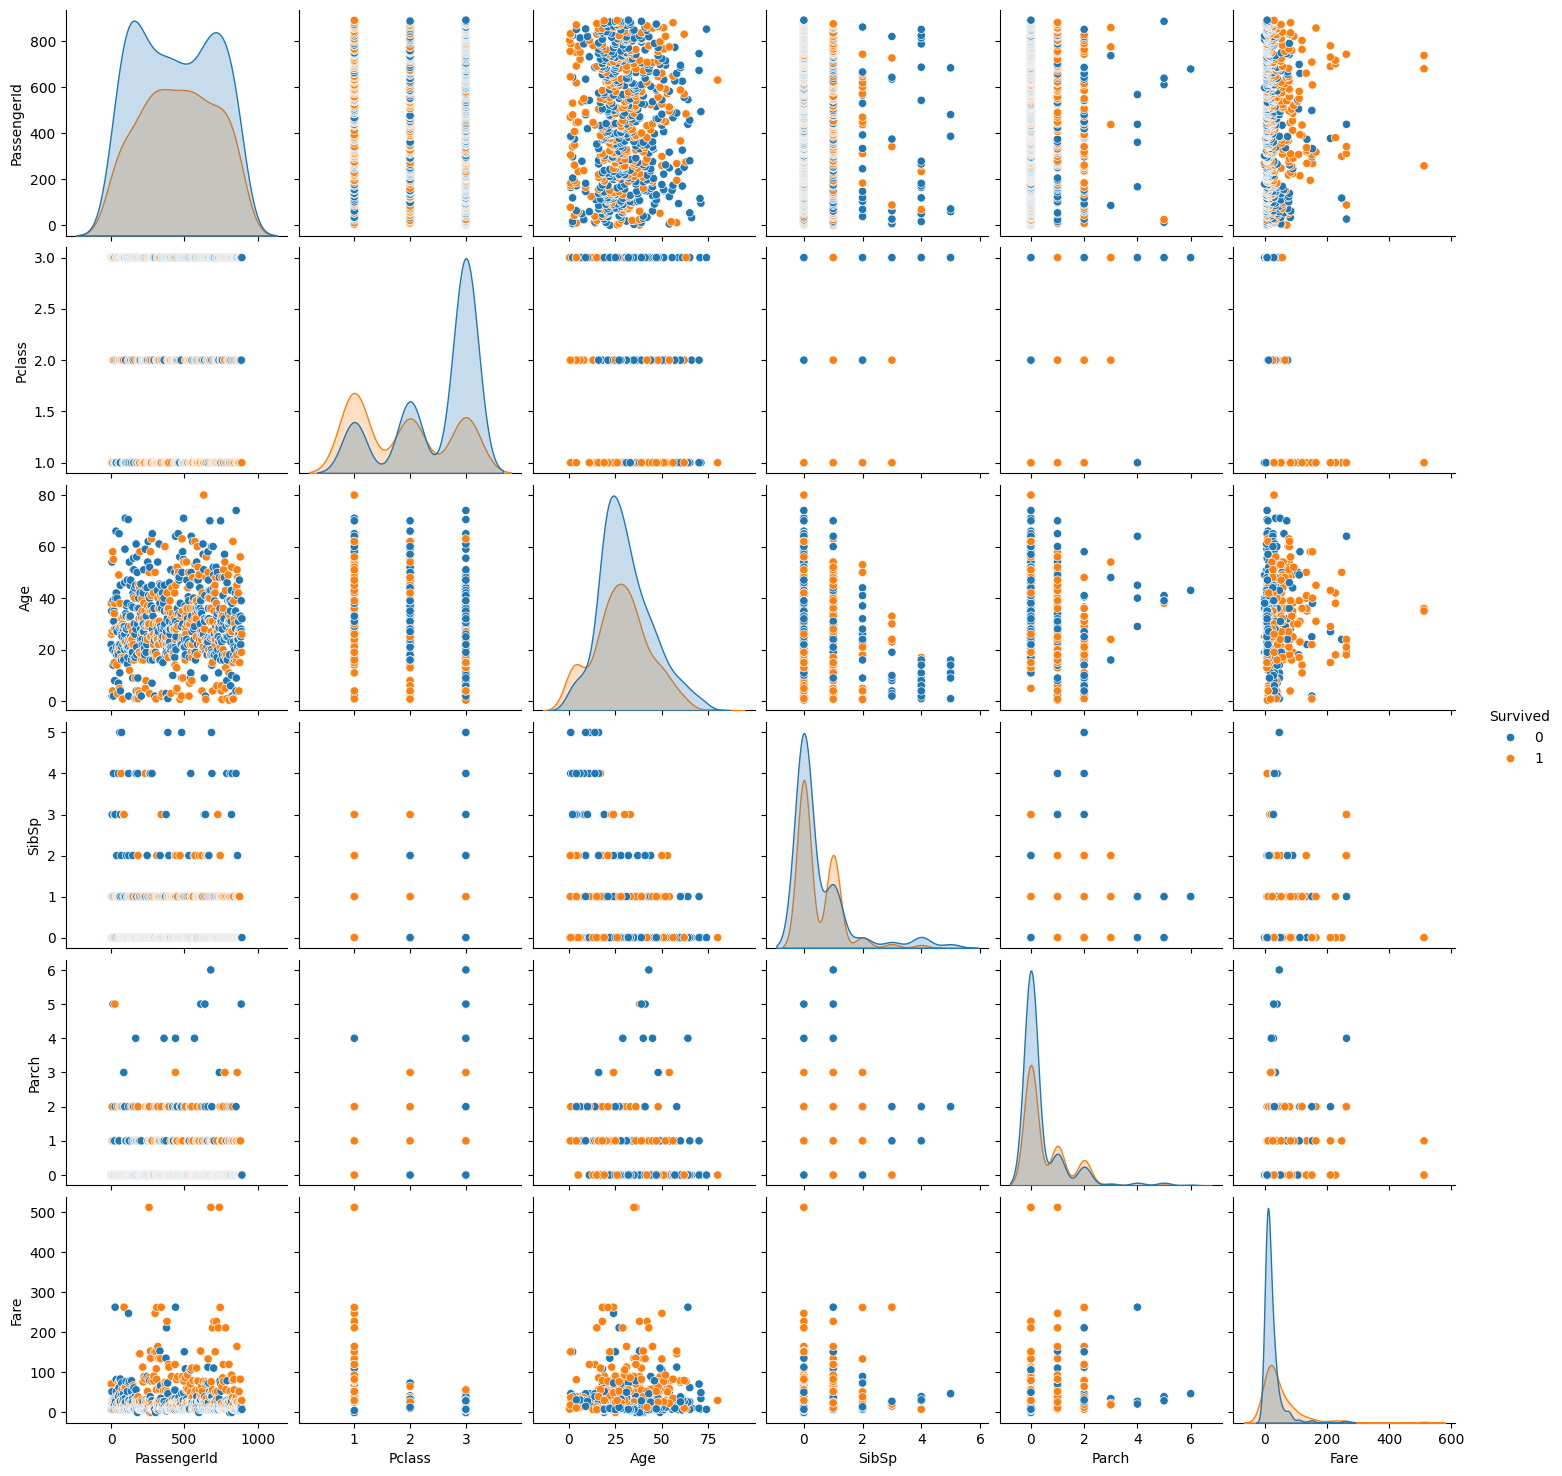

In [35]:
# Pairplot of numerical features
sns.pairplot(df[num_cols].dropna(), hue="Survived", diag_kind='kde')

Standard analysis looks at individuals. However, families on the Titanic often lived or died together. You can identify groups by looking for people with the same Surname and Ticket number.

Text(0.5, 1.0, 'Survival Consistency within Family Groups')

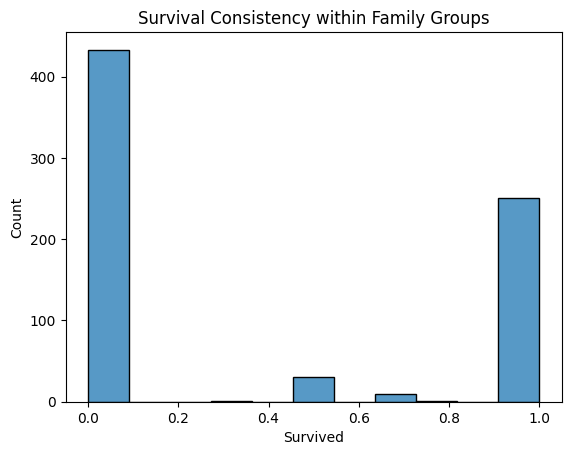

In [36]:
# Extract Surname
df['Surname'] = df['Name'].apply(lambda x: x.split(',')[0])

# Create a 'FamilyGroup' identifier
df['FamilyGroup'] = df['Surname'] + "_" + df['Ticket'].str[:-1]

# Find survival rates of these groups
group_survival = df.groupby('FamilyGroup')['Survived'].mean()
sns.histplot(group_survival)
plt.title("Survival Consistency within Family Groups")

The Cabin column is 77% null, so most people drop it. However, the Letter in the cabin (A, B, C, D, E, F, G, T) represents the Deck. Decks closer to the water line had lower survival rates.

Text(0.5, 1.0, 'Survival Rate by Ship Deck (Vertical Location)')

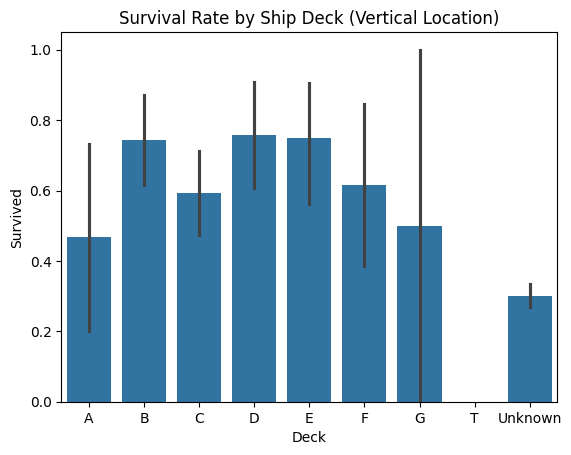

In [37]:
# Extract Deck from Cabin
df['Deck'] = df['Cabin'].str.slice(0,1)
df['Deck'] = df['Deck'].fillna('Unknown')

# Plot Deck vs Survival, ordered by vertical height of the ship
deck_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'Unknown']
sns.barplot(data=df, x='Deck', y='Survived', order=deck_order)
plt.title("Survival Rate by Ship Deck (Vertical Location)")

Is there a "survival ceiling" for wealth? Instead of a scatter plot, use a cumulative distribution or a "Binned" bar plot to see if paying $100 vs $500 actually changed your odds.

Text(0.5, 1.0, 'Survival Probability by Fare Quintiles')

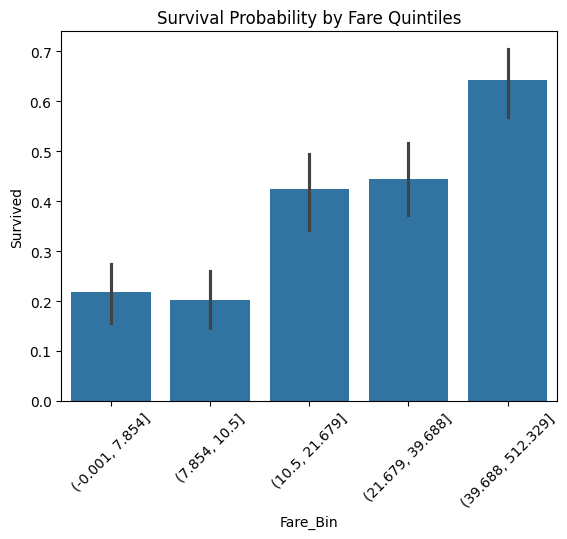

In [38]:
df["Fare_Bin"] = pd.qcut(df["Fare"], 5)

sns.barplot(data=df, x='Fare_Bin', y="Survived")
plt.xticks(rotation=45)
plt.title("Survival Probability by Fare Quintiles")

Some passengers traveled on the same ticket but weren't "Family" (e.g., nannies, friends, or cousins). The frequency of a ticket number tells you the total group size, which is often more accurate than SibSp + Parch.

Text(0.5, 1.0, 'Survival Rate by Group Size (based on Ticket Frequency)')

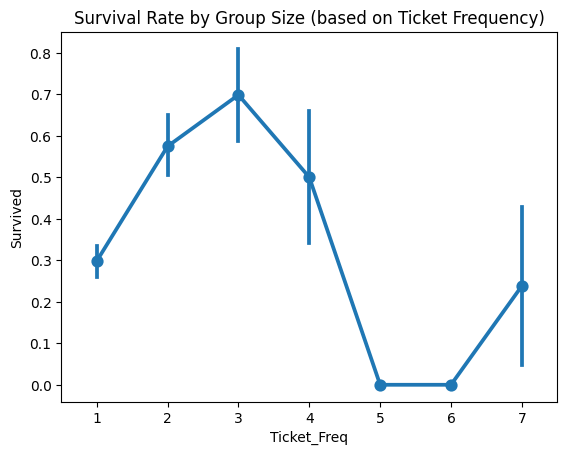

In [39]:
df["Ticket_Freq"] = df.groupby("Ticket")["Ticket"].transform('count')
sns.pointplot(data=df, x='Ticket_Freq', y='Survived')
plt.title("Survival Rate by Group Size (based on Ticket Frequency)")

Many people just fill missing Age with the median. To see if the missingness itself is a signal, check if people with "Missing Age" survived at different rates than those with "Known Age."

Text(0.5, 1.0, 'Survival Rate: Known Age vs. Missing Age')

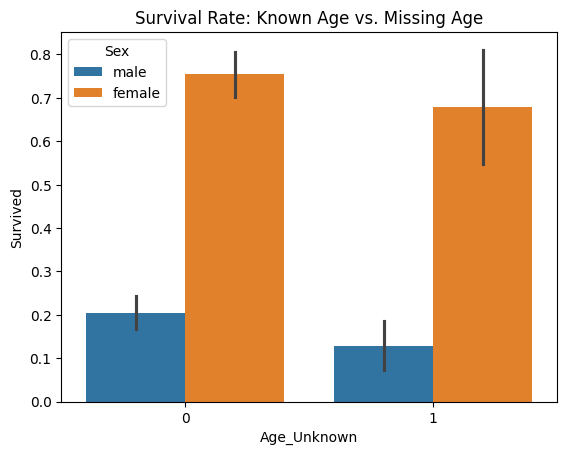

In [40]:
df["Age_Unknown"] = df["Age"].isnull().astype(int)
sns.barplot(data=df, x="Age_Unknown", y="Survived", hue="Sex")
plt.title("Survival Rate: Known Age vs. Missing Age")